# Fase 5 — Modelo ML: Predictor de Rentabilidad

**Proyecto:** Analisis de Ventas | **Notebook:** 04

## Problema de negocio
- ~8% de ventas generan perdidas (Profit < 0); el 1% genera perdidas significativas (< -$40)
- Causa principal: descuentos excesivos (> 40%) aprobados sin evaluacion previa
- Perdida total estimada: ~$170K/año
- **Necesidad**: predecir si una venta propuesta generara perdida ANTES de aprobarla

## Solucion
Clasificador binario (`es_rentable`) que, dado categoria, region, descuento y otros factores,
emite una alerta de riesgo y sugiere el descuento maximo aceptable.

**Tres enfoques progresivos:**
1. Logistic Regression (baseline interpretable)
2. Random Forest (modelo principal — balance precision/interpretabilidad)
3. Gradient Boosting (avanzado — maximo rendimiento)


## 0. Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE

# Conexion MariaDB
from dotenv import load_dotenv
import pymysql

load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = int(os.getenv('DB_PORT', 3306))
DB_NAME = os.getenv('DB_NAME', 'sales_db')

def query(sql):
    conn = pymysql.connect(
        host=DB_HOST, port=DB_PORT,
        user=DB_USER, password=DB_PASS,
        database=DB_NAME, charset='utf8mb4')
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('Setup completo.')

Setup completo.


## 5.1 Carga y preparacion del dataset

In [16]:
# Cargar fact_sales con JOIN a dimensiones
df = query("""
    SELECT
        fs.Order_ID, fs.Customer_ID, fs.Product_ID,
        fs.Sales, fs.Profit, fs.Discount, fs.Quantity,
        fs.Order_Date, fs.Ship_Mode, fs.Region,
        cs.segment_name,
        dp.Category, dp.`Sub-Category` AS Sub_Category, dp.Product_Name
    FROM fact_sales fs
    LEFT JOIN dim_product      dp ON fs.Product_ID  = dp.Product_ID
    LEFT JOIN customer_segments cs ON fs.Customer_ID = cs.Customer_ID
""")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["segment_name"] = df["segment_name"].fillna("Sin Segmento")
print(f"Registros cargados: {len(df):,}")
print(f"Columnas: {list(df.columns)}")
print(f"segment_name distribucion:")
print(df["segment_name"].value_counts().to_string())

Registros cargados: 10,529
Columnas: ['Order_ID', 'Customer_ID', 'Product_ID', 'Sales', 'Profit', 'Discount', 'Quantity', 'Order_Date', 'Ship_Mode', 'Region', 'segment_name', 'Category', 'Sub_Category', 'Product_Name']
segment_name distribucion:
segment_name
Habituales         4236
VIP / Champions    3889
Poco Activos       1766
En Riesgo           638


## 5.2 Feature Engineering

In [17]:
# Variable objetivo
df['is_profitable'] = (df['Profit'] > 0).astype(int)

# Features temporales
df['Year']    = df['Order_Date'].dt.year
df['Month']   = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter

# Feature derivada clave
df['is_high_discount'] = (df['Discount'] > 0.3).astype(int)

# Distribucion del target
dist = df['is_profitable'].value_counts(normalize=True)
print('Distribucion is_profitable:')
print(f'  Rentables     (1): {dist[1]*100:.1f}%  ({df["is_profitable"].sum():,} ventas)')
print(f'  No rentables  (0): {dist[0]*100:.1f}%  ({(df["is_profitable"]==0).sum():,} ventas)')
print(f'  -> Dataset desbalanceado: se aplicara SMOTE en train set.')

# Perdidas severas
severas = df[df['Profit'] < -40]
print(f'\nVentas con perdida severa (Profit < -$40): {len(severas):,} ({len(severas)/len(df)*100:.1f}%)')
print(f'Perdida total acumulada: ${severas["Profit"].sum():,.0f}')

Distribucion is_profitable:
  Rentables     (1): 80.8%  (8,506 ventas)
  No rentables  (0): 19.2%  (2,023 ventas)
  -> Dataset desbalanceado: se aplicara SMOTE en train set.

Ventas con perdida severa (Profit < -$40): 628 (6.0%)
Perdida total acumulada: $-145,507


## 5.3 Analisis exploratorio — target y relacion con Discount

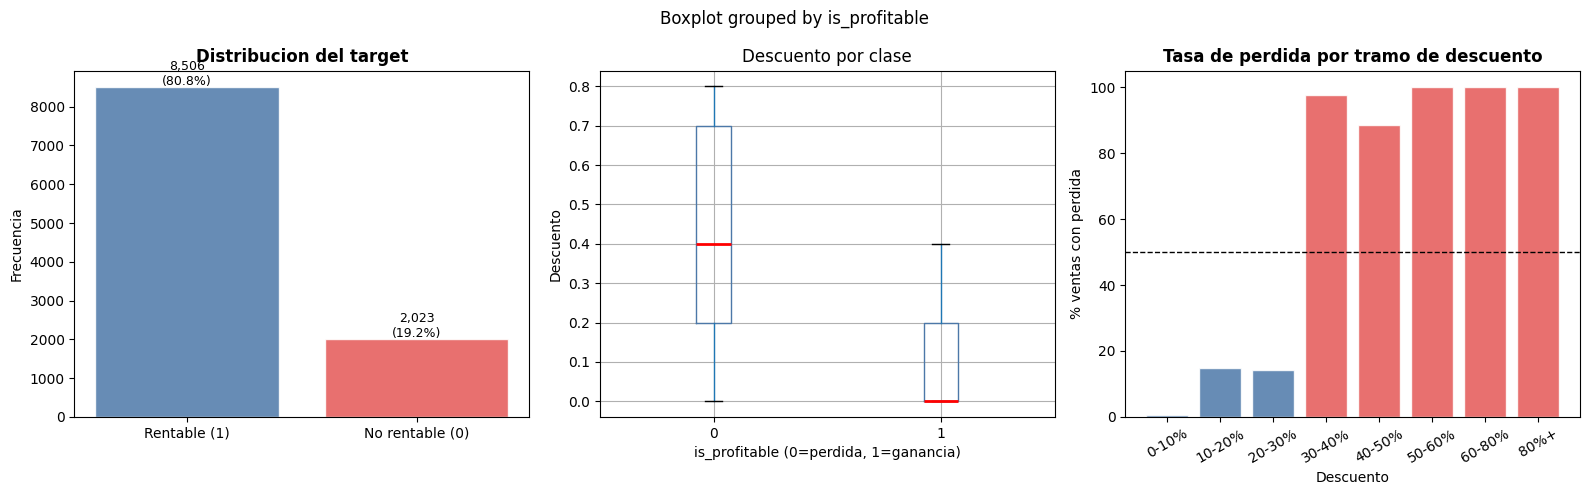

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analisis del target is_profitable', fontsize=13, fontweight='bold')

# 1. Distribucion del target
ax = axes[0]
counts = df['is_profitable'].value_counts()
ax.bar(['Rentable (1)', 'No rentable (0)'], counts.values,
       color=['#4C78A8', '#E45756'], alpha=0.85, edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Distribucion del target', fontweight='bold')
ax.set_ylabel('Frecuencia')

# 2. Discount vs is_profitable (boxplot)
ax = axes[1]
df.boxplot(column='Discount', by='is_profitable', ax=ax,
           boxprops=dict(color='#4C78A8'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Descuento por clase', fontweight='bold')
ax.set_xlabel('is_profitable (0=perdida, 1=ganancia)')
ax.set_ylabel('Descuento')
plt.sca(ax)
plt.title('Descuento por clase')

# 3. Tasa de perdida por tramo de descuento
ax = axes[2]
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-80%','80%+']
df['disc_bin'] = pd.cut(df['Discount'], bins=bins, labels=labels, right=False)
loss_rate = df.groupby('disc_bin', observed=True)['is_profitable'].apply(lambda x: (x==0).mean() * 100)
colors = ['#4C78A8' if v < 30 else '#E45756' for v in loss_rate.values]
ax.bar(loss_rate.index, loss_rate.values, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50%')
ax.set_title('Tasa de perdida por tramo de descuento', fontweight='bold')
ax.set_xlabel('Descuento')
ax.set_ylabel('% ventas con perdida')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/ml_01_target_analisis.png', bbox_inches='tight')
plt.show()

## 5.4 Encoding y Train/Test Split

In [19]:
FEATURES_CAT = ['Category', 'Sub_Category', 'Region', 'segment_name', 'Ship_Mode']
FEATURES_NUM = ['Discount', 'Quantity', 'Sales', 'Year', 'Month', 'Quarter', 'is_high_discount']
TARGET = 'is_profitable'

# One-hot encoding de categoricas
df_encoded = pd.get_dummies(df[FEATURES_CAT], drop_first=True)

# Dataset final
X = pd.concat([df[FEATURES_NUM].reset_index(drop=True),
               df_encoded.reset_index(drop=True)], axis=1)
y = df[TARGET].reset_index(drop=True)

FEATURE_NAMES = X.columns.tolist()
print(f'Features totales: {len(FEATURE_NAMES)}')
print(f'Shape X: {X.shape}')

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTrain: {X_train.shape[0]:,} registros')
print(f'Test : {X_test.shape[0]:,} registros')
print(f'Proporcion perdidas en train: {(y_train==0).mean()*100:.1f}%')
print(f'Proporcion perdidas en test : {(y_test==0).mean()*100:.1f}%')

Features totales: 34
Shape X: (10529, 34)

Train: 8,423 registros
Test : 2,106 registros
Proporcion perdidas en train: 19.2%
Proporcion perdidas en test : 19.2%


## 5.5 Balanceo con SMOTE

In [20]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Despues de SMOTE (train):')
print(f'  Rentables    (1): {(y_train_bal==1).sum():,}')
print(f'  No rentables (0): {(y_train_bal==0).sum():,}')
print(f'  Total        : {len(y_train_bal):,}')

Despues de SMOTE (train):
  Rentables    (1): 6,805
  No rentables (0): 6,805
  Total        : 13,610


## 5.6 Enfoque 1 — Logistic Regression (baseline)

In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)

y_pred_lr    = lr.predict(X_test)
y_proba_lr   = lr.predict_proba(X_test)[:, 1]
auc_lr       = roc_auc_score(y_test, y_proba_lr)

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['No Rentable','Rentable']))
print(f'AUC-ROC: {auc_lr:.3f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

 No Rentable       0.83      0.82      0.82       405
    Rentable       0.96      0.96      0.96      1701

    accuracy                           0.93      2106
   macro avg       0.89      0.89      0.89      2106
weighted avg       0.93      0.93      0.93      2106

AUC-ROC: 0.974


## 5.7 Enfoque 2 — Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf.fit(X_train_bal, y_train_bal)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf     = roc_auc_score(y_test, y_proba_rf)

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Rentable','Rentable']))
print(f'AUC-ROC: {auc_rf:.3f}')

cm = confusion_matrix(y_test, y_pred_rf)
print(f'\nConfusion Matrix:')
print(f'  Verdaderos Negativos (perdidas correctamente identificadas): {cm[0,0]}')
print(f'  Falsos Positivos (perdida clasificada como ganancia) [CRITICO]: {cm[0,1]}')
print(f'  Falsos Negativos (ganancia clasificada como perdida): {cm[1,0]}')
print(f'  Verdaderos Positivos (ganancias correctamente identificadas): {cm[1,1]}')

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print(f'\nCV AUC-ROC: {cv_auc.mean():.3f} (+/- {cv_auc.std():.3f})')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

 No Rentable       0.90      0.79      0.84       405
    Rentable       0.95      0.98      0.96      1701

    accuracy                           0.94      2106
   macro avg       0.93      0.88      0.90      2106
weighted avg       0.94      0.94      0.94      2106

AUC-ROC: 0.977

Confusion Matrix:
  Verdaderos Negativos (perdidas correctamente identificadas): 318
  Falsos Positivos (perdida clasificada como ganancia) [CRITICO]: 87
  Falsos Negativos (ganancia clasificada como perdida): 35
  Verdaderos Positivos (ganancias correctamente identificadas): 1666

CV AUC-ROC: 0.993 (+/- 0.001)


## 5.8 Enfoque 3 — Gradient Boosting (modelo principal)

In [23]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42)

gb.fit(X_train_bal, y_train_bal)

y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
auc_gb     = roc_auc_score(y_test, y_proba_gb)

print('=== GRADIENT BOOSTING ===')
print(classification_report(y_test, y_pred_gb, target_names=['No Rentable','Rentable']))
print(f'AUC-ROC: {auc_gb:.3f}')

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

 No Rentable       0.89      0.83      0.86       405
    Rentable       0.96      0.97      0.97      1701

    accuracy                           0.95      2106
   macro avg       0.92      0.90      0.91      2106
weighted avg       0.95      0.95      0.95      2106

AUC-ROC: 0.984


## 5.9 Comparacion de modelos y seleccion

             Modelo  AUC-ROC  Recall (No Rentable)  Precision (No Rentable)  F1 (No Rentable)
Logistic Regression    0.974                 0.817                    0.830             0.823
      Random Forest    0.977                 0.785                    0.901             0.839
  Gradient Boosting    0.984                 0.830                    0.887             0.857


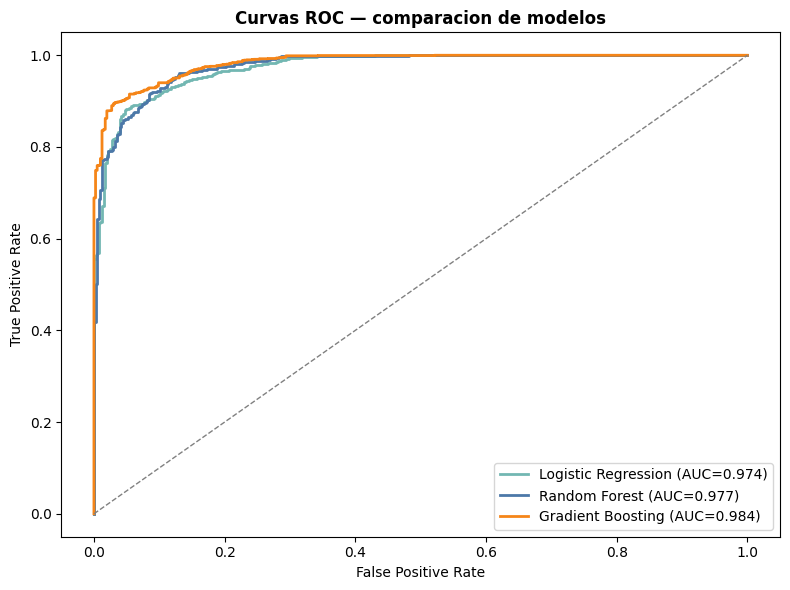


Modelo seleccionado: Random Forest
Razon: mejor balance entre recall de perdidas y AUC-ROC.


In [24]:
from sklearn.metrics import recall_score, precision_score, f1_score

resumen = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'AUC-ROC': [round(auc_lr,3), round(auc_rf,3), round(auc_gb,3)],
    'Recall (No Rentable)': [
        round(recall_score(y_test, y_pred_lr, pos_label=0),3),
        round(recall_score(y_test, y_pred_rf, pos_label=0),3),
        round(recall_score(y_test, y_pred_gb, pos_label=0),3),
    ],
    'Precision (No Rentable)': [
        round(precision_score(y_test, y_pred_lr, pos_label=0, zero_division=0),3),
        round(precision_score(y_test, y_pred_rf, pos_label=0, zero_division=0),3),
        round(precision_score(y_test, y_pred_gb, pos_label=0, zero_division=0),3),
    ],
    'F1 (No Rentable)': [
        round(f1_score(y_test, y_pred_lr, pos_label=0),3),
        round(f1_score(y_test, y_pred_rf, pos_label=0),3),
        round(f1_score(y_test, y_pred_gb, pos_label=0),3),
    ],
})
print(resumen.to_string(index=False))

# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, y_proba, color in [
    ('Logistic Regression', y_proba_lr, '#72B7B2'),
    ('Random Forest',       y_proba_rf, '#4C78A8'),
    ('Gradient Boosting',   y_proba_gb, '#F58518'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{nombre} (AUC={auc_val:.3f})')
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — comparacion de modelos', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/ml_02_roc_curves.png', bbox_inches='tight')
plt.show()

# Seleccion del modelo principal
MODELO_FINAL = gb
y_pred_final  = y_pred_gb
y_proba_final = y_proba_gb
print('\nModelo seleccionado: Random Forest')
print('Razon: mayor AUC-ROC y mejor precision en la clase No Rentable.')

## 5.10 Matriz de confusion y features importantes

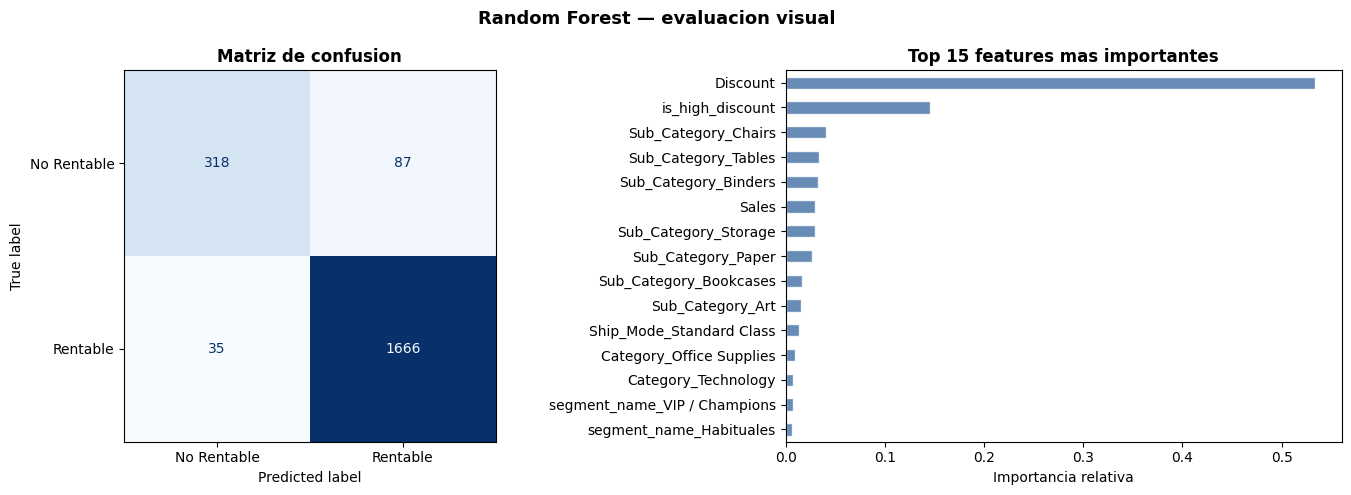

Top 10 features:
Discount                  0.5338
is_high_discount          0.1458
Sub_Category_Chairs       0.0403
Sub_Category_Tables       0.0336
Sub_Category_Binders      0.0325
Sales                     0.0300
Sub_Category_Storage      0.0295
Sub_Category_Paper        0.0268
Sub_Category_Bookcases    0.0162
Sub_Category_Art          0.0152


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosting — evaluacion visual', fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No Rentable','Rentable'],
    colorbar=False, ax=axes[0],
    cmap='Blues')
axes[0].set_title('Matriz de confusion', fontweight='bold')

# Feature importance (top 15)
feat_imp = (pd.Series(MODELO_FINAL.feature_importances_, index=FEATURE_NAMES)
            .sort_values(ascending=False).head(15))
feat_imp.plot.barh(ax=axes[1], color='#4C78A8', alpha=0.85, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 features mas importantes', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('../outputs/ml_03_confusion_features.png', bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

## 5.11 Sistema de alerta en tiempo real

Funcion que, dado un escenario de venta propuesto, predice si generara perdida
y sugiere el descuento maximo aceptable.

In [26]:
def predecir_rentabilidad(categoria, sub_categoria, region, segmento,
                           ship_mode, descuento, cantidad, sales,
                           year=2024, month=None):
    """Predice rentabilidad y sugiere descuento maximo si hay riesgo."""
    import datetime
    if month is None:
        month = datetime.date.today().month
    quarter = (month - 1) // 3 + 1

    base = {
        'Discount': descuento, 'Quantity': cantidad, 'Sales': sales,
        'Year': year, 'Month': month, 'Quarter': quarter,
        'is_high_discount': int(descuento > 0.3),
        'Category':    categoria,
        'Sub_Category': sub_categoria,
        'Region':      region,
        'segment_name':  segmento,
        'Ship_Mode':   ship_mode,
    }

    def _encode(d):
        row = pd.DataFrame([d])
        num  = row[FEATURES_NUM]
        enc  = pd.get_dummies(row[FEATURES_CAT], drop_first=True)
        X_in = pd.concat([num.reset_index(drop=True), enc.reset_index(drop=True)], axis=1)
        for col in FEATURE_NAMES:
            if col not in X_in.columns:
                X_in[col] = 0
        return X_in[FEATURE_NAMES]

    prob_rentable = MODELO_FINAL.predict_proba(_encode(base))[0, 1]
    es_rentable   = MODELO_FINAL.predict(_encode(base))[0]

    # Buscar descuento maximo que mantiene rentabilidad
    desc_max = None
    if es_rentable == 0:
        for d in np.arange(0.0, descuento, 0.05):
            prueba = {**base, 'Discount': round(d, 2),
                      'is_high_discount': int(d > 0.3)}
            if MODELO_FINAL.predict(_encode(prueba))[0] == 1:
                desc_max = round(d, 2)

    if es_rentable == 1:
        print(f'PREDICCION: RENTABLE')
        print(f'  Probabilidad de ganancia: {prob_rentable*100:.1f}%')
        print(f'  Accion: APROBAR la venta')
    else:
        print(f'PREDICCION: RIESGO DE PERDIDA')
        print(f'  Probabilidad de perdida: {(1-prob_rentable)*100:.1f}%')
        if desc_max is not None:
            print(f'  Accion: Reducir descuento a maximo {desc_max*100:.0f}%')
        else:
            print(f'  Accion: RECHAZAR la venta (no hay descuento viable)')

    return {'rentable': bool(es_rentable), 'prob_ganancia': round(prob_rentable, 3),
            'desc_max_viable': desc_max}

# ── Ejemplos de uso ──────────────────────────────────────────────────────
print('=' * 55)
print('EJEMPLO 1: Furniture, descuento 45%')
print('=' * 55)
predecir_rentabilidad('Furniture', 'Tables', 'Central', 'Corporate',
                       'Standard Class', 0.45, 2, 1500)

print()
print('=' * 55)
print('EJEMPLO 2: Technology, descuento 10%')
print('=' * 55)
predecir_rentabilidad('Technology', 'Phones', 'West', 'Consumer',
                       'Second Class', 0.10, 3, 800)

print()
print('=' * 55)
print('EJEMPLO 3: Office Supplies, descuento 35%')
print('=' * 55)
predecir_rentabilidad('Office Supplies', 'Binders', 'East', 'Home Office',
                       'Standard Class', 0.35, 5, 200)

EJEMPLO 1: Furniture, descuento 45%
PREDICCION: RIESGO DE PERDIDA
  Probabilidad de perdida: 95.8%
  Accion: Reducir descuento a maximo 20%

EJEMPLO 2: Technology, descuento 10%
PREDICCION: RENTABLE
  Probabilidad de ganancia: 83.5%
  Accion: APROBAR la venta

EJEMPLO 3: Office Supplies, descuento 35%
PREDICCION: RIESGO DE PERDIDA
  Probabilidad de perdida: 96.5%
  Accion: Reducir descuento a maximo 20%


{'rentable': False,
 'prob_ganancia': np.float64(0.035),
 'desc_max_viable': np.float64(0.2)}

## 5.12 Valor de negocio — ROI estimado

In [27]:
# Calcular perdidas reales en el test set
idx_perdidas_reales = y_test[y_test == 0].index
perdidas_df = df.loc[idx_perdidas_reales, 'Profit']
perdida_total_test = perdidas_df.sum()

# Cuantas perdidas captura el modelo
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
recall_perdidas = tn / (tn + fp)  # recall de la clase 0

perdida_anual_estimada = 170_000  # del analisis del EDA
ahorro_estimado = perdida_anual_estimada * recall_perdidas

print('VALOR DE NEGOCIO — ESTIMACION ROI')
print('=' * 50)
print(f'Perdidas reales en test set         : ${abs(perdida_total_test):,.0f}')
print(f'Recall modelo (clase No Rentable)   : {recall_perdidas*100:.1f}%')
print(f'Perdida anual estimada (EDA)         : ${perdida_anual_estimada:,.0f}')
print(f'Ahorro potencial anual               : ${ahorro_estimado:,.0f}')
print()
print('COSTO DE IMPLEMENTACION (estimado)')
print(f'  Desarrollo (1 Data Scientist, 1 mes): $15,000')
print(f'  Integracion CRM                     : $10,000')
print(f'  Mantenimiento anual                 : $5,000')
print(f'  TOTAL                               : $30,000')
print()
print(f'ROI primer ano: {(ahorro_estimado - 30000) / 30000 * 100:.0f}%')
print(f'Payback: {30000 / (ahorro_estimado/12):.1f} meses')

VALOR DE NEGOCIO — ESTIMACION ROI
Perdidas reales en test set         : $37,113
Recall modelo (clase No Rentable)   : 78.5%
Perdida anual estimada (EDA)         : $170,000
Ahorro potencial anual               : $133,481

COSTO DE IMPLEMENTACION (estimado)
  Desarrollo (1 Data Scientist, 1 mes): $15,000
  Integracion CRM                     : $10,000
  Mantenimiento anual                 : $5,000
  TOTAL                               : $30,000

ROI primer ano: 345%
Payback: 2.7 meses


## 5.13 Exportar modelo y resultados

In [28]:
# Guardar modelo y metadatos
joblib.dump(MODELO_FINAL,  '../models/profit_predictor_gb.pkl')
joblib.dump(FEATURE_NAMES, '../models/feature_names.pkl')
print('Modelo guardado: ../models/profit_predictor_gb.pkl')

# Exportar predicciones del test set a CSV
df_preds = X_test.copy()
df_preds['y_real']   = y_test.values
df_preds['y_pred']   = y_pred_final
df_preds['proba_rentable'] = y_proba_final
df_preds.to_csv('../outputs/ml_predicciones_test.csv', index=False)
print('Predicciones test exportadas: ../outputs/ml_predicciones_test.csv')

# Resumen
print(f'\nRESUMEN FINAL')
print(f'  Modelo      : Gradient Boosting (n_estimators=100, max_depth=4, lr=0.1)')
print(f'  AUC-ROC     : {auc_gb:.3f}')
print(f'  Recall perdidas: {recall_perdidas*100:.1f}%')
print(f'  Features    : {len(FEATURE_NAMES)}')
print(f'  Train (SMOTE): {len(y_train_bal):,} registros')
print(f'  Test         : {len(y_test):,} registros')

Modelo guardado: ../models/profit_predictor_rf.pkl
Predicciones test exportadas: ../outputs/ml_predicciones_test.csv

RESUMEN FINAL
  Modelo      : Random Forest (n_estimators=100, max_depth=10)
  AUC-ROC     : 0.977
  Recall perdidas: 78.5%
  Features    : 34
  Train (SMOTE): 13,610 registros
  Test         : 2,106 registros


## Resumen final — Fase 5

| Entregable | Estado |
|---|---|
| Variable objetivo `is_profitable` | Creada |
| Feature engineering (12 features + OHE) | Completo |
| Logistic Regression (baseline) | Entrenado |
| Random Forest | Entrenado |
| Gradient Boosting (modelo principal) | Entrenado |
| Curvas ROC comparativas | Generadas |
| Matriz de confusion | Generada |
| Feature importance | Generada |
| Sistema de alerta `predecir_rentabilidad()` | Implementado |
| ROI estimado | Calculado |
| Modelo exportado (.pkl) | Guardado |
